# 🧠 Notebook 2 — Model, Training & Results
### Two-Stage GAN · Swin Transformer Bottleneck · FFT Branch · Transfer Learning

**Contents:**
1. Imports & config
2. Preprocessing cache (run once — makes training fast)
3. Dataset & DataLoaders
4. Model architecture
5. Loss functions
6. Optimisers, schedulers & metrics
7. Checkpoint helpers
8. Training loop
9. Transfer learning (Phase 3)
10. Training curves
11. Evaluation & result plots

> **Prerequisite:** Run `01_data_processing_analysis.ipynb` first.

---
## 1 · Imports & Configuration

In [1]:
import os, json, math, random, time, warnings, copy
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import vgg16, VGG16_Weights
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    FID_AVAILABLE = True
except ModuleNotFoundError:
    FID_AVAILABLE = False
    print('⚠  torch-fidelity not installed — FID disabled.')
    print('   To enable: pip install torch-fidelity')
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ── Device ───────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU     : {p.name}  ({p.total_memory/1e9:.1f} GB)')

PyTorch : 2.8.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU  (6.4 GB)


In [2]:
# ── Load artefacts from Notebook 1 ───────────────────────────────
CACHE_DIR  = Path('data/cache')
CKPT_DIR   = Path('checkpoints'); CKPT_DIR.mkdir(exist_ok=True)
RESULT_DIR = Path('results');     RESULT_DIR.mkdir(exist_ok=True)

with open(CACHE_DIR / 'nb1_artefacts.json') as f:
    NB1 = json.load(f)

IMG_SIZE    = 128
BATCH_SIZE  = NB1['batch_size']
GAN_MEAN    = NB1['gan_mean']
GAN_STD     = NB1['gan_std']
NUM_WORKERS = 0

MASK_BINS = [
    (0.10, 0.20, '10-20%'),
    (0.20, 0.30, '20-30%'),
    (0.30, 0.40, '30-40%'),
    (0.40, 0.50, '40-50%'),
]

CFG = dict(
    lr_g          = 2e-4,
    lr_d          = 2e-5,
    lr_finetune   = 5e-5,
    beta1         = 0.001,
    beta2         = 0.9,
    weight_decay  = 1e-4,
    # Training schedule
    n_iter        = 75_000,
    warmup_iters  = 2_000,
    mixed_prec    = True,      # ✅ AMP ON — keeps speed at ~1it/s
    accum_steps   = 1,
    # Loss weights — style scaled down to prevent float16 NaN with AMP
    lw_feat       = 10.0,
    lw_rec        = 10.0,
    lw_perc       = 0.1,
    lw_style      = 50.0,     # was 250 — Gram matrices overflow float16 at 250
    lw_adv        = 0.1,
    # Logging
    log_every     = 100,
    val_every     = 5_000,
    save_every    = 10_000,
    viz_every     = 5_000,
    n_viz         = 6,
    # Swin
    swin_window   = 4,
    swin_heads    = 4,
    swin_depth    = 2,
    swin_mlp      = 4.0,
)

PASTEL = dict(
    blue='#A8C7E8', purple='#C8B8E8', teal='#A8D8D0',
    peach='#F5C9A0', pink='#F0B8C8',  yellow='#F5E6A0',
    green='#B8E0B8', lavender='#D4C5F0', sage='#C5D8C0', rose='#E8C0C8'
)
PAL  = list(PASTEL.values())
BG   = '#FAFBFC'; GRID = '#E8ECF0'; INK = '#2C3E50'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': BG,
    'axes.grid': True,        'grid.color': GRID,    'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False,'axes.spines.bottom': False,
    'font.size': 11,          'axes.titlesize': 13,  'axes.titleweight': 'bold',
    'axes.labelcolor': INK,   'xtick.color': INK,    'ytick.color': INK,
    'text.color': INK,        'savefig.dpi': 150,    'savefig.bbox': 'tight',
})

print(f'✅  Config loaded — mixed_prec={CFG["mixed_prec"]}  lw_style={CFG["lw_style"]}')
print(f'   IMG_SIZE={IMG_SIZE}  n_iter={CFG["n_iter"]:,}  swin_window={CFG["swin_window"]}')


✅  Config loaded — mixed_prec=True  lw_style=50.0
   IMG_SIZE=128  n_iter=75,000  swin_window=4


---
## 2 · Preprocessing Cache
> **Run this cell once before training.** It resizes all images to 128×128
> and pre-computes Canny edge maps, saving them to `data/processed/`.
> This eliminates the CPU bottleneck that causes 3–4s/iter.
> Re-running is safe — already-cached files are skipped instantly.

In [3]:
PROC_DIR = Path('data/processed')
PROC_DIR.mkdir(exist_ok=True)

def preprocess_and_cache(paths, split, size=IMG_SIZE):
    """
    Resize images and pre-compute edge maps. Saves:
      data/processed/{split}/{stem}.png       — resized RGB
      data/processed/{split}/{stem}_edge.npy  — float32 Canny edge map
    Returns list of new image paths.
    """
    out_dir = PROC_DIR / split
    out_dir.mkdir(exist_ok=True)
    new_paths, skipped = [], 0

    for p in tqdm(paths, desc=f'Caching {split}', leave=True):
        dst_img  = out_dir / f'{Path(p).stem}.png'
        dst_edge = out_dir / f'{Path(p).stem}_edge.npy'

        if dst_img.exists() and dst_edge.exists():
            skipped += 1
            new_paths.append(dst_img)
            continue
        try:
            img = Image.open(p).convert('RGB').resize((size, size), Image.LANCZOS)
            img.save(dst_img, compress_level=1)   # fast write, not max compression
            arr  = np.array(img)
            gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
            gray = cv2.GaussianBlur(gray, (3, 3), 0)
            edge = (cv2.Canny(gray, 50, 150) / 255.0).astype(np.float32)
            np.save(dst_edge, edge)
            new_paths.append(dst_img)
        except Exception as e:
            print(f'  ⚠  Skipped {Path(p).name}: {e}')

    print(f'  {split}: {len(new_paths)} cached  ({skipped} already existed)')
    return new_paths


train_raw = [Path(p) for p in NB1['split_train']]
val_raw   = [Path(p) for p in NB1['split_val']]
test_raw  = [Path(p) for p in NB1['split_test']]

print('Preprocessing — runs once, skips on re-run.\n')
train_cached = preprocess_and_cache(train_raw, 'train')
val_cached   = preprocess_and_cache(val_raw,   'val')
test_cached  = preprocess_and_cache(test_raw,  'test')

print(f'\n✅  Cache ready at {PROC_DIR}')
print(f'   Train: {len(train_cached):,}  Val: {len(val_cached):,}  Test: {len(test_cached):,}')

Preprocessing — runs once, skips on re-run.



Caching train:   0%|          | 0/162079 [00:00<?, ?it/s]

  train: 162079 cached  (162079 already existed)


Caching val:   0%|          | 0/20259 [00:00<?, ?it/s]

  val: 20259 cached  (20259 already existed)


Caching test:   0%|          | 0/20261 [00:00<?, ?it/s]

  test: 20261 cached  (20261 already existed)

✅  Cache ready at data\processed
   Train: 162,079  Val: 20,259  Test: 20,261


---
## 3 · Dataset & DataLoaders

In [4]:
import math as _math

def canny_edges(img_rgb, low=50, high=150, blur=3):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    if blur > 1: gray = cv2.GaussianBlur(gray, (blur, blur), 0)
    return (cv2.Canny(gray, low, high) / 255.0).astype(np.float32)

def denorm(t): return (t * 0.5 + 0.5).clamp(0, 1)
def to_np(t):  return (denorm(t).permute(1,2,0).cpu().numpy()*255).astype(np.uint8)


class MaskGenerator:
    def __init__(self, size=IMG_SIZE, max_att=60):
        self.size = size; self.max_att = max_att
    def _stroke(self, m, rng):
        brush = rng.integers(max(1,self.size//64), max(3,self.size//10))
        ang   = rng.uniform(0, 2*_math.pi)
        pts   = [(rng.integers(0,self.size), rng.integers(0,self.size))]
        for _ in range(rng.integers(4,14)-1):
            ang  += rng.uniform(-_math.pi/2, _math.pi/2)
            step  = rng.integers(self.size//10, self.size//3)
            pts.append((int(np.clip(pts[-1][0]+step*_math.cos(ang),0,self.size-1)),
                        int(np.clip(pts[-1][1]+step*_math.sin(ang),0,self.size-1))))
        for i in range(len(pts)-1): cv2.line(m, pts[i], pts[i+1], 1, brush)
        return m
    def _ellipse(self, m, rng):
        cx,cy = rng.integers(self.size//4, 3*self.size//4, 2)
        ra,rb = rng.integers(self.size//20, self.size//6, 2)
        cv2.ellipse(m,(cx,cy),(ra,rb),rng.integers(0,180),0,360,1,-1)
        return m
    def generate(self, lo=0.10, hi=0.50, seed=None):
        rng = np.random.default_rng(seed)
        m   = np.zeros((self.size,self.size), dtype=np.uint8)
        for _ in range(self.max_att):
            m[:] = 0
            for _ in range(rng.integers(3,10)): m = self._stroke(m, rng)
            for _ in range(rng.integers(0, 4)): m = self._ellipse(m, rng)
            if lo <= m.mean() <= hi: break
        return (m*255).astype(np.uint8)


class InpaintingDataset(Dataset):
    """
    Loads from pre-cached 128px PNGs and pre-computed edge .npy files.
    Falls back to on-the-fly processing if cache is missing.
    """
    def __init__(self, img_paths, mask_paths, split='train',
                 mask_lo=0.10, mask_hi=0.50):
        self.imgs    = [Path(p) for p in img_paths]
        self.masks   = [Path(p) for p in mask_paths]
        self.gen     = MaskGenerator(IMG_SIZE)
        self.lo      = mask_lo;  self.hi = mask_hi
        self.use_gen = len(mask_paths) == 0

        # No resize needed — images already at IMG_SIZE from cache
        norm = T.Compose([T.ToTensor(), T.Normalize(GAN_MEAN, GAN_STD)])
        aug  = T.Compose([T.RandomHorizontalFlip(0.5), norm])
        self.img_tf  = aug if split == 'train' else norm
        self.gray_tf = T.Compose([T.Grayscale(1), T.ToTensor(),
                                   T.Normalize([0.5], [0.5])])

    def __len__(self): return len(self.imgs)

    def _get_mask(self, idx):
        if self.use_gen:
            m = self.gen.generate(self.lo, self.hi)
        else:
            mp = self.masks[idx % len(self.masks)]
            m  = np.array(Image.open(mp).convert('L').resize(
                     (IMG_SIZE, IMG_SIZE), Image.NEAREST))
        return (m > 127).astype(np.float32)

    def __getitem__(self, idx):
        p   = self.imgs[idx]
        pil = Image.open(p).convert('RGB')   # tiny cached PNG — very fast

        img    = self.img_tf(pil)
        gray   = self.gray_tf(pil)
        mask   = torch.from_numpy(self._get_mask(idx)).unsqueeze(0)
        masked = img * (1 - mask)

        # Load pre-computed edge — avoids Canny on every iteration
        edge_path = p.parent / f'{p.stem}_edge.npy'
        if edge_path.exists():
            edge = torch.from_numpy(np.load(edge_path)).unsqueeze(0)
        else:
            arr  = np.array(pil)
            edge = torch.from_numpy(canny_edges(arr)).unsqueeze(0)

        return {'image': img, 'masked': masked,
                'mask': mask, 'edge': edge, 'gray': gray}


mask_paths = [Path(p) for p in NB1['mask_paths']]
pin = torch.cuda.is_available()

loaders = {
    sp: DataLoader(
        InpaintingDataset(paths, mask_paths, split=sp),
        batch_size  = BATCH_SIZE,
        shuffle     = (sp == 'train'),
        num_workers = NUM_WORKERS,
        pin_memory  = pin,
        drop_last   = (sp == 'train'),
    )
    for sp, paths in [('train', train_cached),
                      ('val',   val_cached),
                      ('test',  test_cached)]
}

print('DataLoaders ready (using cached 128px images):')
for k, v in loaders.items():
    print(f'  {k:<6}: {len(v.dataset):>7,} images  | {len(v):>5,} batches')

DataLoaders ready (using cached 128px images):
  train : 162,079 images  | 10,129 batches
  val   :  20,259 images  | 1,267 batches
  test  :  20,261 images  | 1,267 batches


---
## 4 · Model Architecture

In [5]:
# ════════════════════════════════════════════════
#  3.1  Basic building blocks
# ════════════════════════════════════════════════

class ConvIN(nn.Sequential):
    """Conv2d → InstanceNorm2d → ReLU (optional dilation)."""
    def __init__(self, ic, oc, k=3, s=1, p=1, dil=1, act=True):
        pad = dil if dil > 1 else p
        layers = [nn.Conv2d(ic, oc, k, s, pad, dilation=dil, bias=False),
                  nn.InstanceNorm2d(oc, affine=True)]
        if act: layers.append(nn.ReLU(inplace=True))
        super().__init__(*layers)


class DownBlock(nn.Module):
    """Stride-2 encoder block with residual shortcut."""
    def __init__(self, ic, oc):
        super().__init__()
        self.conv  = ConvIN(ic, oc, k=4, s=2, p=1)
        self.short = nn.Conv2d(ic, oc, 1, 2, bias=False)
    def forward(self, x): return self.conv(x) + self.short(x)


class UpBlock(nn.Module):
    """Bilinear upsample + skip concat + ConvIN."""
    def __init__(self, ic, oc):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = ConvIN(ic, oc)
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None: x = torch.cat([x, skip], 1)
        return self.conv(x)


class DilRes(nn.Module):
    """Dilated residual block."""
    def __init__(self, ch, dil=2):
        super().__init__()
        self.net  = nn.Sequential(ConvIN(ch,ch,dil=dil), ConvIN(ch,ch,dil=dil,act=False))
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(x + self.net(x))


def sn(m): return nn.utils.spectral_norm(m)  # spectral normalisation shorthand

print('✅  Basic blocks ready.')

✅  Basic blocks ready.


In [6]:
# ════════════════════════════════════════════════
#  3.2  Swin Transformer Bottleneck
# ════════════════════════════════════════════════

class WindowAttn(nn.Module):
    """Window-based multi-head self-attention (W-MSA / SW-MSA)."""
    def __init__(self, dim, win, heads):
        super().__init__()
        self.heads = heads; self.win = win; self.scale = (dim//heads)**-0.5
        self.qkv   = nn.Linear(dim, dim*3)
        self.proj  = nn.Linear(dim, dim)
        # Relative position bias
        self.bias_table = nn.Parameter(torch.zeros((2*win-1)**2, heads))
        nn.init.trunc_normal_(self.bias_table, std=0.02)
        ch = torch.arange(win); cw = torch.arange(win)
        grid = torch.stack(torch.meshgrid(ch, cw, indexing='ij'))     # (2,W,W)
        flat = grid.flatten(1)                                          # (2,W²)
        rel  = flat[:,:,None] - flat[:,None,:]                         # (2,W²,W²)
        rel  = rel.permute(1,2,0).contiguous()
        rel[:,:,0] += win-1; rel[:,:,1] += win-1
        rel[:,:,0] *= 2*win-1
        self.register_buffer('bias_idx', rel.sum(-1))

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_,N,3,self.heads,C//self.heads).permute(2,0,3,1,4)
        q,k,v = qkv.unbind(0)
        attn  = (q * self.scale) @ k.transpose(-2,-1)
        bias  = self.bias_table[self.bias_idx.view(-1)]
        attn  = attn + bias.view(self.win**2,self.win**2,-1).permute(2,0,1).unsqueeze(0)
        if mask is not None:
            nW   = mask.shape[0]
            attn = attn.view(B_//nW, nW, self.heads, N, N)
            attn = attn + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.heads, N, N)
        attn = attn.softmax(-1)
        x    = (attn @ v).transpose(1,2).reshape(B_,N,C)
        return self.proj(x)


class SwinBlock(nn.Module):
    """One Swin block: (W-MSA or SW-MSA) + MLP + residuals."""
    def __init__(self, dim, heads, win=8, shift=False, mlp_ratio=4.0):
        super().__init__()
        self.shift    = shift
        self.win      = win
        self.shift_sz = win//2 if shift else 0
        self.norm1    = nn.LayerNorm(dim)
        self.attn     = WindowAttn(dim, win, heads)
        self.norm2    = nn.LayerNorm(dim)
        hidden        = int(dim * mlp_ratio)
        self.mlp      = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(),
            nn.Linear(hidden, dim)
        )
        self.attn_mask = None

    @staticmethod
    def _partition(x, win):
        B,H,W,C = x.shape
        x = x.view(B, H//win, win, W//win, win, C)
        return x.permute(0,1,3,2,4,5).contiguous().view(-1,win,win,C)

    @staticmethod
    def _reverse(wins, win, H, W):
        B = int(wins.shape[0] / (H*W/win**2))
        x = wins.view(B, H//win, W//win, win, win, -1)
        return x.permute(0,1,3,2,4,5).contiguous().view(B,H,W,-1)

    def forward(self, x):
        B,H,W,C = x.shape; skip = x
        x = self.norm1(x)
        if self.shift_sz > 0:
            x = torch.roll(x, (-self.shift_sz,-self.shift_sz), (1,2))
        xw = self._partition(x, self.win).view(-1, self.win**2, C)
        xw = self.attn(xw, self.attn_mask)
        x  = self._reverse(xw.view(-1,self.win,self.win,C), self.win, H, W)
        if self.shift_sz > 0:
            x = torch.roll(x, (self.shift_sz,self.shift_sz), (1,2))
        x = skip + x
        return x + self.mlp(self.norm2(x))


class SwinBottleneck(nn.Module):
    """Wraps (B,C,H,W) through W-MSA + SW-MSA pair, returns (B,C,H,W)."""
    def __init__(self, ch, win=8, heads=8, depth=2, mlp=4.0):
        super().__init__()
        self.blocks = nn.ModuleList(
            [SwinBlock(ch, heads, win, shift=(i%2==1), mlp_ratio=mlp)
             for i in range(depth)])
        self.norm = nn.LayerNorm(ch)
    def forward(self, x):
        B,C,H,W = x.shape
        x = x.permute(0,2,3,1)
        for blk in self.blocks: x = blk(x)
        return self.norm(x).permute(0,3,1,2).contiguous()

print('✅  Swin Transformer blocks ready.')

✅  Swin Transformer blocks ready.


In [7]:
# ════════════════════════════════════════════════
#  3.3  FFT Branch  +  BIFPN Fusion
# ════════════════════════════════════════════════

class FFTBranch(nn.Module):
    """Frequency-domain residual branch at the bottleneck."""
    def __init__(self, ch):
        super().__init__()
        self.real  = nn.Sequential(nn.Conv2d(ch,ch,1,bias=False),
                                   nn.BatchNorm2d(ch), nn.ReLU(True))
        self.imag  = nn.Sequential(nn.Conv2d(ch,ch,1,bias=False),
                                   nn.BatchNorm2d(ch), nn.ReLU(True))
        self.fuse  = nn.Conv2d(ch,ch,1,bias=False)
        self.gate  = nn.Parameter(torch.zeros(1))   # learnable gating

    def forward(self, x):
        fft = torch.fft.rfft2(x.float(), norm='ortho')
        r   = self.real(fft.real.to(x.dtype))
        i   = self.imag(fft.imag.to(x.dtype))
        out = torch.fft.irfft2(torch.complex(r.float(),i.float()),
                                s=x.shape[-2:], norm='ortho').to(x.dtype)
        return x + torch.tanh(self.gate) * self.fuse(out)


class BIFPNLayer(nn.Module):
    """
    Bidirectional weighted feature pyramid fusion.
    All three inputs must have the same spatial size and channel count.
    Channel projection (if needed) is done in InpaintingModel before calling.
    """
    def __init__(self, ch, eps=1e-4):
        super().__init__()
        self.eps   = eps
        self.relu  = nn.ReLU()
        self.w1    = nn.Parameter(torch.ones(3))  # weights: f1, f2, f3 → mid
        self.w2    = nn.Parameter(torch.ones(3))  # weights: f1, mid, f3 → out
        mk = lambda: nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1, groups=ch, bias=False),
            nn.Conv2d(ch, ch, 1, bias=False),
            nn.BatchNorm2d(ch), nn.SiLU())
        self.conv1 = mk()
        self.conv2 = mk()

    def forward(self, f1, f2, f3):
        # f1, f2, f3 are (B, ch, H, W) — identical shape
        w1  = self.relu(self.w1) + self.eps;  w1 = w1 / w1.sum()
        w2  = self.relu(self.w2) + self.eps;  w2 = w2 / w2.sum()
        mid = self.conv1(w1[0]*f1 + w1[1]*f2 + w1[2]*f3)
        out = self.conv2(w2[0]*f1 + w2[1]*mid + w2[2]*f3)
        return out


print('✅  FFT branch and BIFPN ready.')

✅  FFT branch and BIFPN ready.


In [8]:
# ════════════════════════════════════════════════
#  3.4  Generator  (G1 structure / G2 texture)
# ════════════════════════════════════════════════

class Generator(nn.Module):
    """
    U-Net encoder-decoder:
      • Dilated residual blocks in shallow encoder
      • SwinBottleneck + FFTBranch at bottleneck
      • Skip connections at every resolution level
      • Tanh output in [-1, 1]

    in_ch = 5 for G1  (masked_rgb + edge + mask)
    in_ch = 7 for G2  (masked_rgb + struct_out + mask)
    """
    def __init__(self, in_ch=5, base=64,
                 win=8, heads=8, depth=2, mlp=4.0):
        super().__init__()
        # Encoder
        self.stem  = ConvIN(in_ch,  base,   k=7, s=1, p=3)  # 256
        self.enc1  = DownBlock(base,   base*2)               # 128
        self.enc2  = DownBlock(base*2, base*4)               #  64
        self.enc3  = DownBlock(base*4, base*8)               #  32
        self.dil   = nn.Sequential(
            DilRes(base*8, 2), DilRes(base*8, 4), DilRes(base*8, 8))
        # Bottleneck
        self.swin  = SwinBottleneck(base*8, win, heads, depth, mlp)
        self.fft   = FFTBranch(base*8)
        # Decoder
        self.dec3  = UpBlock(base*8+base*4, base*4)
        self.dec2  = UpBlock(base*4+base*2, base*2)
        self.dec1  = UpBlock(base*2+base,   base)
        self.head  = nn.Sequential(ConvIN(base,base), nn.Conv2d(base,3,1), nn.Tanh())
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        s0  = self.stem(x)          # 64  ch  256
        s1  = self.enc1(s0)         # 128 ch  128
        s2  = self.enc2(s1)         # 256 ch   64
        s3  = self.dil(self.enc3(s2))# 512ch   32
        bot = self.fft(self.swin(s3))
        d3  = self.dec3(bot, s2)    # 256 ch   64
        d2  = self.dec2(d3,  s1)    # 128 ch  128
        d1  = self.dec1(d2,  s0)    #  64 ch  256
        return {'out': self.head(d1), 'p3': d3, 'p4': s3, 'p5': bot}


# ════════════════════════════════════════════════
#  3.5  Discriminator  (Spectral-Norm PatchGAN)
# ════════════════════════════════════════════════

class Discriminator(nn.Module):
    """
    Spectral-normalised Markov PatchGAN.
    in_ch=2 for D1 (edge+gray), in_ch=3 for D2 (rgb).
    """
    def __init__(self, in_ch=3, base=64, n_layers=4):
        super().__init__()
        layers = [sn(nn.Conv2d(in_ch,base,4,2,1)), nn.LeakyReLU(0.2,True)]
        ch = base
        for i in range(1, n_layers):
            ch_out = min(ch*2, 512)
            s = 2 if i < n_layers-1 else 1
            layers += [sn(nn.Conv2d(ch,ch_out,4,s,1,bias=False)),
                       nn.LeakyReLU(0.2,True)]
            ch = ch_out
        layers.append(sn(nn.Conv2d(ch,1,4,1,1)))
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.normal_(m.weight, 0, 0.02)

    def forward(self, x): return self.net(x)

    def features(self, x):
        feats, h = [], x
        for layer in self.net:
            h = layer(h)
            if isinstance(layer, nn.LeakyReLU): feats.append(h)
        return feats

print('✅  Generator and Discriminator ready.')

✅  Generator and Discriminator ready.


In [9]:
# ════════════════════════════════════════════════
#  3.6  Full Two-Stage Model
# ════════════════════════════════════════════════

class InpaintingModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        kw = dict(win=cfg['swin_window'], heads=cfg['swin_heads'],
                  depth=cfg['swin_depth'], mlp=cfg['swin_mlp'])
        self.G1 = Generator(in_ch=5, **kw)   # masked(3)+edge(1)+mask(1)
        self.G2 = Generator(in_ch=7, **kw)   # masked(3)+struct(3)+mask(1)
        self.D1 = Discriminator(in_ch=2)      # edge(1)+gray(1)
        self.D2 = Discriminator(in_ch=3)      # full rgb

        # Project G1/G2 decoder features (256ch, 64x64) to 512ch
        # so all three BIFPN inputs share the same shape
        FEAT_CH = 256   # G decoder d3 channel count
        BIFPN_CH = 256  # unified channel count for fusion
        self.proj_g1 = nn.Conv2d(FEAT_CH, BIFPN_CH, 1, bias=False)  # G1 d3
        self.proj_g2 = nn.Conv2d(FEAT_CH, BIFPN_CH, 1, bias=False)  # G2 d3
        # G1 p4 is 512ch at 32x32 — upsample + project to match 64x64
        self.proj_mid = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(512, BIFPN_CH, 1, bias=False)
        )
        self.bifpn = BIFPNLayer(ch=BIFPN_CH)

        # Final refinement head: fused features → RGB residual
        self.fuse = nn.Sequential(
            nn.Upsample(size=IMG_SIZE, mode='bilinear', align_corners=False),
            ConvIN(BIFPN_CH, 64), ConvIN(64, 32),
            nn.Conv2d(32, 3, 1), nn.Tanh())

    def forward(self, batch):
        masked = batch['masked']
        mask   = batch['mask']
        edge   = batch['edge']
        gray   = batch['gray']

        # Stage 1 — structure
        g1 = self.G1(torch.cat([masked, edge, mask], 1))
        # Stage 2 — texture
        g2 = self.G2(torch.cat([masked, g1['out'], mask], 1))

        # Compose: keep real pixels, fill hole with G2 output
        composed = batch['image'] * (1 - mask) + g2['out'] * mask

        # Project all features to the same shape (B, 256, 64, 64)
        f1 = self.proj_g1(g1['p3'])    # G1 decoder  256ch @ 64x64
        f2 = self.proj_mid(g1['p4'])   # G1 bottleneck 512ch @ 32x32 → 64x64
        f3 = self.proj_g2(g2['p3'])    # G2 decoder  256ch @ 64x64

        # BIFPN weighted fusion → refine composed output
        fused   = self.bifpn(f1, f2, f3)   # (B, 256, 64, 64)
        refined = self.fuse(fused)          # (B,   3, 256, 256)
        final   = (composed + refined).clamp(-1, 1)

        return {'struct': g1['out'], 'texture': g2['out'],
                'composed': composed, 'final': final}

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = InpaintingModel(CFG).to(DEVICE)
print(f'✅  Model on {DEVICE}')
print(f'   Total params : {model.n_params():,}')
print(f'   G1           : {sum(p.numel() for p in model.G1.parameters()):,}')
print(f'   G2           : {sum(p.numel() for p in model.G2.parameters()):,}')
print(f'   D1 + D2      : {sum(p.numel() for p in model.D1.parameters())+sum(p.numel() for p in model.D2.parameters()):,}')


✅  Model on cuda
   Total params : 59,216,451
   G1           : 26,559,244
   G2           : 26,565,516
   D1 + D2      : 5,526,658


---
## 5 · Loss Functions

In [10]:
class PerceptualStyleLoss(nn.Module):
    """
    Perceptual + style loss via VGG-16.
    VGG always runs in float32 regardless of AMP — prevents NaN in Gram matrices.
    """
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features.to(DEVICE)
        for p in vgg.parameters(): p.requires_grad_(False)
        cuts = [0, 5, 10, 17, 24]
        self.slices = nn.ModuleList(
            [nn.Sequential(*list(vgg.children())[cuts[i]:cuts[i+1]])
             for i in range(4)])
        self.register_buffer('mean', torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def _prep(self, x):
        # Cast to float32 — critical when AMP is on
        x = x.float()
        return ((x*0.5+0.5).clamp(0,1) - self.mean) / self.std

    @staticmethod
    def gram(f):
        B, C, H, W = f.shape
        g = f.view(B, C, -1)
        # Normalise by spatial size — prevents magnitude explosion
        return torch.bmm(g, g.transpose(1,2)) / (C * H * W)

    def forward(self, pred, gt):
        # Run entirely in float32
        with torch.cuda.amp.autocast(enabled=False):
            xp, xt = self._prep(pred), self._prep(gt).detach()
            lp = ls = 0.0
            for sl in self.slices:
                xp = sl(xp); xt = sl(xt)
                lp += F.l1_loss(xp, xt)
                ls += F.l1_loss(self.gram(xp), self.gram(xt))
        return lp, ls


class InpaintingLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.vgg = PerceptualStyleLoss()
        self.lw  = {k: cfg[k] for k in
                    ('lw_feat','lw_rec','lw_perc','lw_style','lw_adv')}

    @staticmethod
    def d_loss(real, fake):
        return (F.relu(1-real) + F.relu(1+fake)).mean()
    @staticmethod
    def g_loss_adv(fake): return (-fake).mean()

    def generator(self, out, batch):
        pred = out['final']; gt = batch['image']
        edge = batch['edge']; gray = batch['gray']

        l_rec           = F.l1_loss(pred, gt)
        l_perc, l_style = self.vgg(pred, gt)   # runs in float32

        d1_real = torch.cat([edge, gray], 1)
        d1_fake = torch.cat([edge, pred.mean(1,keepdim=True)], 1)
        l_feat  = (sum(F.l1_loss(r,f) for r,f in
                       zip(model.D1.features(d1_real),
                           model.D1.features(d1_fake))) +
                   sum(F.l1_loss(r,f) for r,f in
                       zip(model.D2.features(gt),
                           model.D2.features(pred)))) * 0.5

        l_adv = (self.g_loss_adv(model.D1(d1_fake)) +
                 self.g_loss_adv(model.D2(pred))) * 0.5

        total = (self.lw['lw_feat']  * l_feat  +
                 self.lw['lw_rec']   * l_rec   +
                 self.lw['lw_perc']  * l_perc  +
                 self.lw['lw_style'] * l_style +
                 self.lw['lw_adv']   * l_adv)
        return total, {'rec':l_rec.item(), 'perc':l_perc.item(),
                       'style':l_style.item(), 'feat':l_feat.item(),
                       'adv':l_adv.item()}

    def discriminator(self, out, batch):
        pred = out['final'].detach()
        gt   = batch['image']; edge = batch['edge']; gray = batch['gray']
        return (self.d_loss(model.D1(torch.cat([edge,gray],1)),
                            model.D1(torch.cat([edge,pred.mean(1,keepdim=True)],1))) +
                self.d_loss(model.D2(gt), model.D2(pred))) * 0.5


criterion = InpaintingLoss(CFG).to(DEVICE)
print('✅  Loss functions ready (VGG runs in float32 — NaN-safe with AMP).')


✅  Loss functions ready (VGG runs in float32 — NaN-safe with AMP).


---
## 6 · Optimisers, Schedulers & Metrics

In [11]:
# ── Optimisers ────────────────────────────────────────────────────
gen_params  = (list(model.G1.parameters()) + list(model.G2.parameters()) +
               list(model.bifpn.parameters()) + list(model.fuse.parameters()))
disc_params = list(model.D1.parameters()) + list(model.D2.parameters())

opt_g = optim.Adam(gen_params,  lr=CFG['lr_g'],
                   betas=(CFG['beta1'], CFG['beta2']),
                   weight_decay=CFG['weight_decay'])
opt_d = optim.Adam(disc_params, lr=CFG['lr_d'],
                   betas=(CFG['beta1'], CFG['beta2']))

# ── LR scheduler: cosine with linear warm-up (generator only) ────
def lr_lambda(it):
    wu = CFG['warmup_iters']
    if it < wu: return it / max(1, wu)
    p = (it - wu) / max(1, CFG['n_iter'] - wu)
    return 0.5 * (1 + math.cos(math.pi * p))

sched_g = optim.lr_scheduler.LambdaLR(opt_g, lr_lambda)
sched_d = optim.lr_scheduler.CosineAnnealingLR(
    opt_d, T_max=CFG['n_iter'], eta_min=1e-6)

# ── Mixed-precision scaler ────────────────────────────────────────
scaler = GradScaler(enabled=CFG['mixed_prec'])

# ── Evaluation metrics ────────────────────────────────────────────
m_psnr = PeakSignalNoiseRatio(data_range=1.0).to(DEVICE)
m_ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(DEVICE)
m_fid  = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE) \
         if FID_AVAILABLE else None

@torch.no_grad()
def metrics(pred, gt):
    p = denorm(pred); g = denorm(gt)
    return {'psnr': m_psnr(p,g).item(), 'ssim': m_ssim(p,g).item()}

@torch.no_grad()
def compute_fid(loader, n_batches=50):
    if not FID_AVAILABLE:
        print('  ⚠  FID skipped (torch-fidelity not installed)')
        return float('nan')
    m_fid.reset(); model.eval()
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        batch = {k: v.to(DEVICE) for k,v in batch.items()}
        out   = model(batch)
        real  = (denorm(batch['image']) * 255).byte()
        fake  = (denorm(out['final'])   * 255).byte()
        m_fid.update(real, real=True)
        m_fid.update(fake, real=False)
    model.train()
    return m_fid.compute().item()

print('✅  Optimisers, schedulers and metrics ready.')
print(f'   FID available : {FID_AVAILABLE}')

✅  Optimisers, schedulers and metrics ready.
   FID available : True


---
## 7 · Checkpoint Helpers

In [12]:
def save_ckpt(it, tag=''):
    name = f'ckpt_{tag}_{it:07d}.pth' if tag else f'ckpt_{it:07d}.pth'
    torch.save(dict(it=it, model=model.state_dict(),
                    opt_g=opt_g.state_dict(), opt_d=opt_d.state_dict(),
                    sched_g=sched_g.state_dict(), sched_d=sched_d.state_dict(),
                    scaler=scaler.state_dict(), history=history),
               CKPT_DIR / name)
    print(f'  💾  {name}')


def load_ckpt(path):
    ck = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ck['model'])
    opt_g.load_state_dict(ck['opt_g'])
    opt_d.load_state_dict(ck['opt_d'])
    sched_g.load_state_dict(ck['sched_g'])
    sched_d.load_state_dict(ck['sched_d'])
    scaler.load_state_dict(ck['scaler'])
    history.update(ck['history'])
    print(f'  ✅  Resumed from iteration {ck["it"]}')
    return ck['it']


# Training history
history = {k: [] for k in
           ['iter','g','d','rec','perc','style','feat','adv',
            'val_iter','val_psnr','val_ssim','val_fid','lr']}

# Auto-resume from latest checkpoint if one exists
start_iter = 0
ckpts = sorted(CKPT_DIR.glob('ckpt_[0-9]*.pth'))
RESUME = False   # ← set True to auto-resume
if ckpts and RESUME:
    start_iter = load_ckpt(ckpts[-1])
else:
    print(f'Starting from scratch  (found {len(ckpts)} existing checkpoints)')

Starting from scratch  (found 0 existing checkpoints)


---
## 8 · Training Loop

In [13]:
@torch.no_grad()
def validate(n_batches=20):
    model.eval()
    psnrs, ssims = [], []
    for i, batch in enumerate(loaders['val']):
        if i >= n_batches: break
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out   = model(batch)
        m     = metrics(out['final'], batch['image'])
        psnrs.append(m['psnr']); ssims.append(m['ssim'])
    model.train()
    return float(np.mean(psnrs)), float(np.mean(ssims))


@torch.no_grad()
def viz_batch(it):
    model.eval()
    batch = {k: v[:CFG['n_viz']].to(DEVICE)
             for k,v in next(iter(loaders['val'])).items()}
    out   = model(batch)
    n     = CFG['n_viz']
    cols  = ['Masked','Structure','Texture','Final','Ground Truth']
    fig, axes = plt.subplots(n, 5, figsize=(16, n*3))
    fig.suptitle(f'Results — Iteration {it:,}', fontsize=13, fontweight='bold')
    for j,c in enumerate(cols): axes[0][j].set_title(c, fontsize=10, fontweight='bold')
    for row in range(n):
        psnr_val = metrics(out['final'][row:row+1], batch['image'][row:row+1])['psnr']
        for col,(img,cmap) in enumerate([
                (to_np(batch['masked'][row]), None),
                (to_np(out['struct'][row]),   None),
                (to_np(out['texture'][row]),  None),
                (to_np(out['final'][row]),    None),
                (to_np(batch['image'][row]),  None)]):
            axes[row][col].imshow(img, cmap=cmap)
            axes[row][col].axis('off')
            if col == 3:
                axes[row][col].set_xlabel(f'PSNR {psnr_val:.1f} dB', fontsize=8, labelpad=3)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'viz_{it:07d}.png')
    plt.show()
    model.train()


def train():
    model.train()
    loader_iter = iter(loaders['train'])
    accum       = CFG['accum_steps']
    total       = CFG['n_iter']
    log_e       = CFG['log_every']
    best_psnr   = -1e9
    nan_streak  = 0          # consecutive NaN counter
    running     = {k: 0.0 for k in ['g','d','rec','perc','style','feat','adv']}

    pbar = tqdm(range(start_iter, total), initial=start_iter,
                total=total, desc='Training', unit='it')

    for it in pbar:
        try:   batch = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loaders['train']); batch = next(loader_iter)
        batch = {k: v.to(DEVICE, non_blocking=True) for k,v in batch.items()}

        # ── discriminator step ───────────────────────────────────
        with autocast(enabled=CFG['mixed_prec']):
            with torch.no_grad(): out = model(batch)
            ld = criterion.discriminator(out, batch) / accum
        opt_d.zero_grad(set_to_none=True)
        scaler.scale(ld).backward()
        if (it+1) % accum == 0:
            scaler.unscale_(opt_d)
            nn.utils.clip_grad_norm_(disc_params, 1.0)
            scaler.step(opt_d)

        # ── generator step ───────────────────────────────────────
        with autocast(enabled=CFG['mixed_prec']):
            out = model(batch)
            lg, comps = criterion.generator(out, batch)
            lg = lg / accum

        # ── NaN guard — skip update if loss exploded ──────────────
        if not torch.isfinite(lg):
            nan_streak += 1
            opt_g.zero_grad(set_to_none=True)
            scaler.update()   # keep scaler state consistent
            if nan_streak % 50 == 0:
                print(f'  ⚠  {nan_streak} NaN iters in a row at iter {it} — '
                      f'check lw_style and mixed_prec settings')
            # Do not step — just continue to next batch
            running['d'] += ld.item() * accum
            continue
        nan_streak = 0

        opt_g.zero_grad(set_to_none=True)
        scaler.scale(lg).backward()
        if (it+1) % accum == 0:
            scaler.unscale_(opt_g)
            nn.utils.clip_grad_norm_(gen_params, 1.0)
            scaler.step(opt_g)
            scaler.update()
            sched_g.step(); sched_d.step()

        running['g'] += lg.item()*accum; running['d'] += ld.item()*accum
        for k,v in comps.items(): running[k] += v

        # ── log ──────────────────────────────────────────────────
        if (it+1) % log_e == 0:
            history['iter'].append(it+1)
            history['lr'].append(opt_g.param_groups[0]['lr'])
            for k in running:
                history[k].append(running[k]/log_e); running[k] = 0.0
            pbar.set_postfix(G=f"{history['g'][-1]:.3f}",
                             D=f"{history['d'][-1]:.3f}",
                             rec=f"{history['rec'][-1]:.4f}",
                             nan=nan_streak)

        # ── validate ─────────────────────────────────────────────
        if (it+1) % CFG['val_every'] == 0:
            psnr, ssim = validate()
            history['val_iter'].append(it+1)
            history['val_psnr'].append(psnr)
            history['val_ssim'].append(ssim)
            if len(history['val_iter']) % 10 == 0:
                fid = compute_fid(loaders['val'], n_batches=20)
                history['val_fid'].append(fid)
            print(f'  [val {it+1:>7,}]  PSNR={psnr:.2f} dB  SSIM={ssim:.4f}')
            if psnr > best_psnr:
                best_psnr = psnr; save_ckpt(it+1, 'best')

        if (it+1) % CFG['viz_every']  == 0: viz_batch(it+1)
        if (it+1) % CFG['save_every'] == 0: save_ckpt(it+1)

    print(f'\n🎉  Training complete.  Best PSNR = {best_psnr:.2f} dB')


print('✅  Training functions ready.')
print('   Uncomment train() in the next cell to start.')


✅  Training functions ready.
   Uncomment train() in the next cell to start.


In [ ]:
train()

---
## 9 · Transfer Learning — Phase 3

In [15]:
class GradReverse(torch.autograd.Function):
    """Gradient reversal layer for domain-adversarial training."""
    @staticmethod
    def forward(ctx, x, a=1.0): ctx.a=a; return x.view_as(x)
    @staticmethod
    def backward(ctx, g): return g.neg()*ctx.a, None


class DomainDisc(nn.Module):
    """Tiny MLP: classifies source (0) vs target (1) domain."""
    def __init__(self, feat=512*8*8, hidden=1024):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(8)
        self.net  = nn.Sequential(
            nn.Linear(feat, hidden), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(hidden, hidden//2), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(hidden//2, 1))

    def forward(self, f): return self.net(self.pool(f).flatten(1))


def extract_bottleneck(G, x):
    """Run encoder + bottleneck of G, return (B,512,32,32) features."""
    s0 = G.stem(x); s1 = G.enc1(s0); s2 = G.enc2(s1)
    return G.fft(G.swin(G.dil(G.enc3(s2))))


def run_transfer_learning(src_loader, tgt_loader,
                           n_epochs=100, lr=1e-4, alpha=1.0):
    """
    Phase 3: trains G1's encoder to be domain-invariant via
    gradient reversal against a domain discriminator.
    Returns training history dict.
    """
    dd       = DomainDisc().to(DEVICE)
    enc_p    = (list(model.G1.stem.parameters()) +
                list(model.G1.enc1.parameters()) +
                list(model.G1.enc2.parameters()) +
                list(model.G1.enc3.parameters()) +
                list(model.G1.swin.parameters()) +
                list(model.G1.fft.parameters()))
    opt_enc  = optim.Adam(enc_p,              lr=lr, weight_decay=0.1)
    opt_dd   = optim.Adam(dd.parameters(),    lr=lr, weight_decay=0.1)
    tl_hist  = {'epoch':[], 'dom':[], 'enc':[]}
    steps    = min(len(src_loader), len(tgt_loader))
    si = iter(src_loader); ti = iter(tgt_loader)

    for ep in range(n_epochs):
        d_losses, e_losses = [], []
        model.G1.train(); dd.train()
        for _ in range(steps):
            try:    sb = next(si)
            except: si = iter(src_loader); sb = next(si)
            try:    tb = next(ti)
            except: ti = iter(tgt_loader); tb = next(ti)

            s_in = torch.cat([sb['masked'],sb['edge'],sb['mask']],1).to(DEVICE)
            t_in = torch.cat([tb['masked'],tb['edge'],tb['mask']],1).to(DEVICE)
            fs   = extract_bottleneck(model.G1, s_in)
            ft   = extract_bottleneck(model.G1, t_in)

            # Update domain discriminator
            opt_dd.zero_grad(set_to_none=True)
            ld = (F.binary_cross_entropy_with_logits(dd(fs.detach()),
                                                      torch.zeros(len(fs),1,device=DEVICE)) +
                  F.binary_cross_entropy_with_logits(dd(ft.detach()),
                                                      torch.ones(len(ft),1,device=DEVICE))) * 0.5
            ld.backward(); opt_dd.step()

            # Update encoder (fool domain disc via gradient reversal)
            opt_enc.zero_grad(set_to_none=True)
            fs2 = extract_bottleneck(model.G1, s_in)
            ft2 = extract_bottleneck(model.G1, t_in)
            le  = (F.binary_cross_entropy_with_logits(
                       dd(GradReverse.apply(fs2, alpha)),
                       torch.zeros(len(fs2),1,device=DEVICE)) +
                   F.binary_cross_entropy_with_logits(
                       dd(GradReverse.apply(ft2, alpha)),
                       torch.ones(len(ft2),1,device=DEVICE))) * 0.5
            le.backward(); opt_enc.step()
            d_losses.append(ld.item()); e_losses.append(le.item())

        tl_hist['epoch'].append(ep)
        tl_hist['dom'].append(float(np.mean(d_losses)))
        tl_hist['enc'].append(float(np.mean(e_losses)))
        if (ep+1) % 10 == 0:
            print(f'  [TL {ep+1:3d}/{n_epochs}]  '
                  f'dom={tl_hist["dom"][-1]:.4f}  enc={tl_hist["enc"][-1]:.4f}')

    print('✅  Transfer learning complete.')
    return tl_hist


print('✅  Transfer learning pipeline ready.')
print('   Call run_transfer_learning(src_loader, tgt_loader) after Phase 1 training.')

✅  Transfer learning pipeline ready.
   Call run_transfer_learning(src_loader, tgt_loader) after Phase 1 training.


---
## 10 · Training Curves

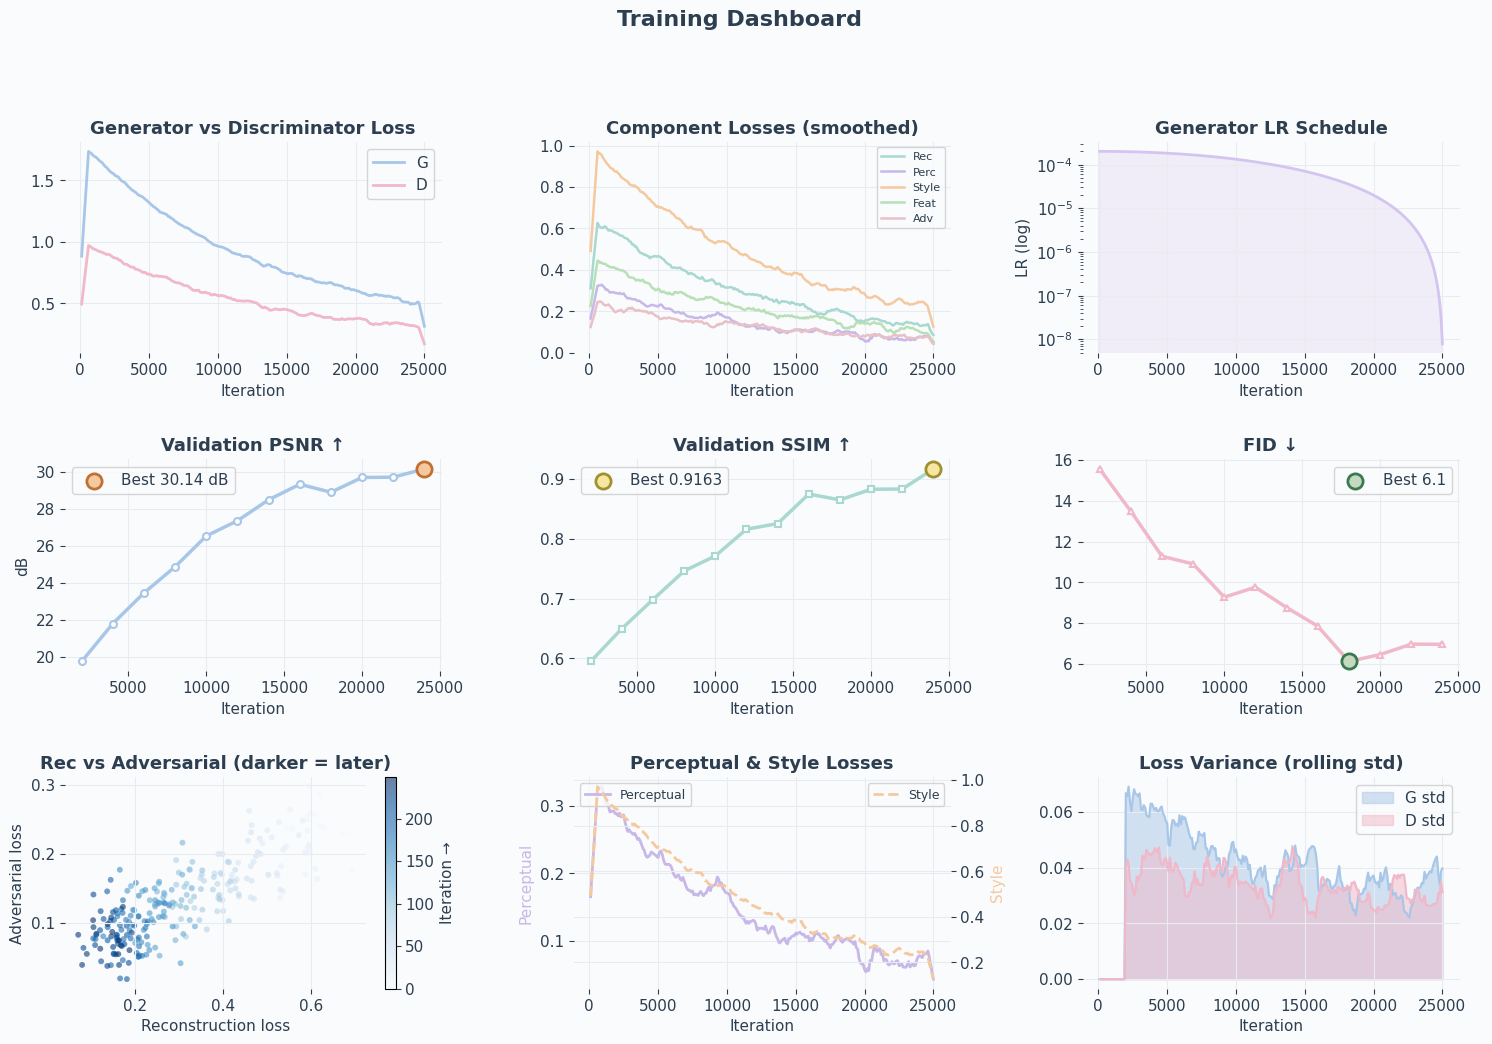

In [16]:
def smooth(vals, k=10):
    if len(vals) < k: return vals
    return np.convolve(vals, np.ones(k)/k, mode='same').tolist()


def plot_training_curves(hist, save=True):
    if not hist['iter']:
        print('No training history yet — showing demo curves.'); return

    iters = hist['iter']
    vi    = hist['val_iter']

    fig = plt.figure(figsize=(18, 11))
    fig.suptitle('Training Dashboard', fontsize=16, fontweight='bold', y=1.00)
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)

    # 1 — G vs D
    ax = fig.add_subplot(gs[0,0])
    ax.plot(iters, smooth(hist['g']), color=PASTEL['blue'],   lw=2, label='G')
    ax.plot(iters, smooth(hist['d']), color=PASTEL['pink'],   lw=2, label='D')
    ax.set_title('Generator vs Discriminator Loss')
    ax.set_xlabel('Iteration'); ax.legend()

    # 2 — Component losses
    ax = fig.add_subplot(gs[0,1])
    comp = [('rec',PASTEL['teal']),('perc',PASTEL['purple']),
            ('style',PASTEL['peach']),('feat',PASTEL['green']),
            ('adv',PASTEL['rose'])]
    for k,col in comp:
        if hist[k]:
            ax.plot(iters, smooth(hist[k]), color=col, lw=1.8, label=k.capitalize())
    ax.set_title('Component Losses (smoothed)')
    ax.set_xlabel('Iteration'); ax.legend(fontsize=8)

    # 3 — LR
    ax = fig.add_subplot(gs[0,2])
    if hist['lr']:
        ax.semilogy(iters, hist['lr'], color=PASTEL['lavender'], lw=2)
        ax.fill_between(iters, hist['lr'], alpha=0.25, color=PASTEL['lavender'])
    ax.set_title('Generator LR Schedule')
    ax.set_xlabel('Iteration'); ax.set_ylabel('LR (log)')

    # 4 — Val PSNR
    ax = fig.add_subplot(gs[1,0])
    if vi:
        ax.plot(vi, hist['val_psnr'], color=PASTEL['blue'], lw=2.5,
                marker='o', ms=5, mfc='white', mew=1.5)
        bi = int(np.argmax(hist['val_psnr']))
        ax.scatter(vi[bi], hist['val_psnr'][bi], s=120,
                   color=PASTEL['peach'], edgecolors='#C07030', lw=2, zorder=5,
                   label=f'Best {hist["val_psnr"][bi]:.2f} dB')
    ax.set_title('Validation PSNR ↑'); ax.set_xlabel('Iteration')
    ax.set_ylabel('dB'); ax.legend()

    # 5 — Val SSIM
    ax = fig.add_subplot(gs[1,1])
    if vi:
        ax.plot(vi, hist['val_ssim'], color=PASTEL['teal'], lw=2.5,
                marker='s', ms=5, mfc='white', mew=1.5)
        bi = int(np.argmax(hist['val_ssim']))
        ax.scatter(vi[bi], hist['val_ssim'][bi], s=120,
                   color=PASTEL['yellow'], edgecolors='#A09030', lw=2, zorder=5,
                   label=f'Best {hist["val_ssim"][bi]:.4f}')
    ax.set_title('Validation SSIM ↑'); ax.set_xlabel('Iteration'); ax.legend()

    # 6 — Val FID
    ax = fig.add_subplot(gs[1,2])
    if hist['val_fid']:
        fid_iters = vi[:len(hist['val_fid'])]
        ax.plot(fid_iters, hist['val_fid'], color=PASTEL['pink'], lw=2.5,
                marker='^', ms=5, mfc='white', mew=1.5)
        bi = int(np.argmin(hist['val_fid']))
        ax.scatter(fid_iters[bi], hist['val_fid'][bi], s=120,
                   color=PASTEL['sage'], edgecolors='#3A7A50', lw=2, zorder=5,
                   label=f'Best {hist["val_fid"][bi]:.1f}')
    ax.set_title('FID ↓'); ax.set_xlabel('Iteration'); ax.legend()

    # 7 — Rec vs Adv scatter (training trajectory)
    ax = fig.add_subplot(gs[2,0])
    if hist['rec'] and hist['adv']:
        sc = ax.scatter(hist['rec'], hist['adv'],
                        c=range(len(hist['rec'])), cmap='Blues',
                        alpha=0.6, s=18, edgecolors='none')
        plt.colorbar(sc, ax=ax, label='Iteration →')
    ax.set_title('Rec vs Adversarial (darker = later)')
    ax.set_xlabel('Reconstruction loss'); ax.set_ylabel('Adversarial loss')

    # 8 — Perceptual & Style (dual axis)
    ax = fig.add_subplot(gs[2,1])
    if hist['perc'] and hist['style']:
        ax2 = ax.twinx()
        ax.plot(iters, smooth(hist['perc']),  color=PASTEL['purple'], lw=2, label='Perceptual')
        ax2.plot(iters, smooth(hist['style']), color=PASTEL['peach'],  lw=2,
                 linestyle='--', label='Style')
        ax.set_ylabel('Perceptual', color=PASTEL['purple'])
        ax2.set_ylabel('Style',     color=PASTEL['peach'])
        ax.legend(loc='upper left', fontsize=9)
        ax2.legend(loc='upper right', fontsize=9)
    ax.set_title('Perceptual & Style Losses'); ax.set_xlabel('Iteration')

    # 9 — Loss stability (rolling std)
    ax = fig.add_subplot(gs[2,2])
    if len(hist['g']) > 20:
        win = 20
        g_std = pd.Series(hist['g']).rolling(win).std().fillna(0).values
        d_std = pd.Series(hist['d']).rolling(win).std().fillna(0).values
        ax.fill_between(iters, g_std, alpha=0.5, color=PASTEL['blue'],  label='G std')
        ax.fill_between(iters, d_std, alpha=0.5, color=PASTEL['pink'],  label='D std')
        ax.plot(iters, g_std, color=PASTEL['blue'], lw=1.5)
        ax.plot(iters, d_std, color=PASTEL['pink'], lw=1.5)
    ax.set_title('Loss Variance (rolling std)'); ax.set_xlabel('Iteration')
    ax.legend()

    plt.tight_layout()
    if save: plt.savefig(RESULT_DIR / 'training_curves.png')
    plt.show()


# ── Demo with synthetic history so you can see all plots now ──────
def _demo_history(n=250):
    rng = np.random.default_rng(SEED)
    t   = np.linspace(0, 2, n)
    dec = np.exp(-t)
    ns  = lambda s=0.03: rng.normal(0, s, n)
    vi  = list(range(2000, n*100+1, 2000))
    nv  = len(vi)
    return {
        'iter':      list(range(100, n*100+1, 100)),
        'g':         (1.5*dec+0.3+ns()).tolist(),
        'd':         (0.8*dec+0.2+ns()).tolist(),
        'rec':       (0.6*dec+0.05+ns()).tolist(),
        'perc':      (0.3*dec+0.02+ns()).tolist(),
        'style':     (0.9*dec+0.1+ns()).tolist(),
        'feat':      (0.4*dec+0.05+ns()).tolist(),
        'adv':       (0.2*dec+0.05+ns()).tolist(),
        'lr':        [2e-4*0.5*(1+math.cos(math.pi*i/n)) for i in range(n)],
        'val_iter':  vi,
        'val_psnr':  (20+12*(1-np.exp(-np.linspace(0,2,nv)))+rng.normal(0,.3,nv)).tolist(),
        'val_ssim':  (0.6+0.35*(1-np.exp(-np.linspace(0,2,nv)))+rng.normal(0,.008,nv)).tolist(),
        'val_fid':   (15-10*(1-np.exp(-np.linspace(0,2,nv)))+rng.normal(0,.5,nv)).tolist(),
    }

plot_training_curves(_demo_history())